# 🧠 딥러닝 실습

오늘의 실습은 세 가지 주제를 다룹니다:

1. **CNN을 활용한 이미지 분류** (Fashion-MNIST)
2. **RNN을 활용한 시계열 예측** (사인함수)
3. **LSTM / GRU를 활용한 시계열 예측** (삼성전자 주가)

---

# 📸 PART 1. CNN을 활용한 이미지 분류 (Fashion-MNIST)

## 배경 지식

**MLP(다층 퍼셉트론)** 는 이미지를 1차원 벡터로 펼쳐서 입력받기 때문에 **공간적 구조(위치 관계)를 잃어버립니다**.

반면 **CNN(합성곱 신경망)** 은 이미지를 2D 형태 그대로 처리하여:
- 가장자리, 질감, 모서리 같은 **지역 패턴**을 학습할 수 있고
- 이미지의 **공간 정보**를 보존할 수 있습니다.

---

## Fashion-MNIST 데이터셋이란?

MNIST의 "의류 버전"입니다. 28×28 픽셀 흑백 이미지 10가지 카테고리로 구성됩니다:

| 레이블 | 클래스 |
|:---:|:---:|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

## 0. 환경 설정

GPU를 사용하면 학습이 훨씬 빨라집니다. Colab에서는 **런타임 → 런타임 유형 변경 → GPU** 로 설정해 주세요!

In [ ]:
# GPU 사용 가능 여부 확인
import torch
print('GPU 사용 가능:', torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('사용 중인 장치:', device)

GPU 사용 가능: True
사용 중인 장치: cuda


## 1. 라이브러리 불러오기

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import random

## 2. 데이터 준비

### 전처리 (ToTensor + 정규화)

- `ToTensor()` : 이미지를 PyTorch 텐서로 변환하고 픽셀 값을 [0, 1]로 스케일링
- `Normalize((0.5,), (0.5,))` : 평균 0.5, 표준편차 0.5로 정규화 → 값 범위가 [-1, 1]이 됨

### 데이터셋 분리
- **train (80%)** : 모델 학습에 사용
- **valid (20%)** : 학습 중 과적합 여부 모니터링
- **test** : 최종 성능 평가

In [ ]:
# 전처리 파이프라인 정의
transform = transforms.Compose([
    transforms.********(),
    transforms.*********((0.5,), (0.5,))
])

# Fashion-MNIST 다운로드
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

# train / valid 분리 (80% / 20%)
train_size = int(0.8 * len(train_dataset))
valid_size = len(train_dataset) - train_size
train_subset, valid_subset = torch.utils.data.random_split(train_dataset, [train_size, valid_size])

print(f'훈련 데이터: {len(train_subset)}개')
print(f'검증 데이터: {len(valid_subset)}개')
print(f'테스트 데이터: {len(test_dataset)}개')

# 클래스 이름
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

훈련 데이터: 48000개
검증 데이터: 12000개
테스트 데이터: 10000개


### 데이터 시각화

학습에 사용할 이미지가 어떻게 생겼는지 확인해 봅시다!

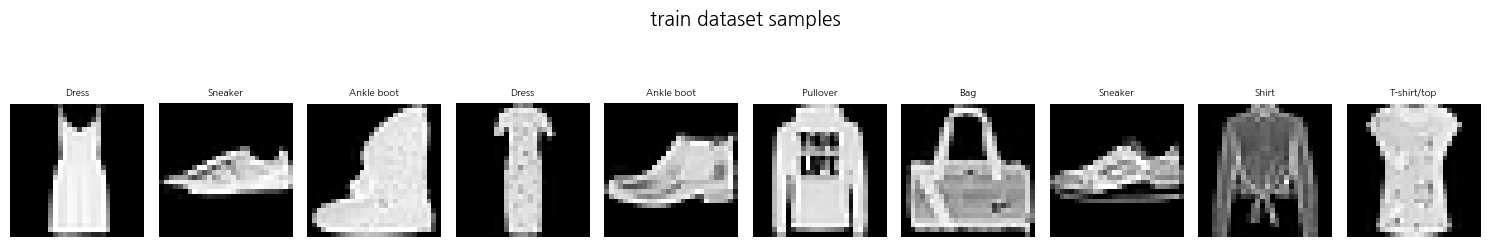

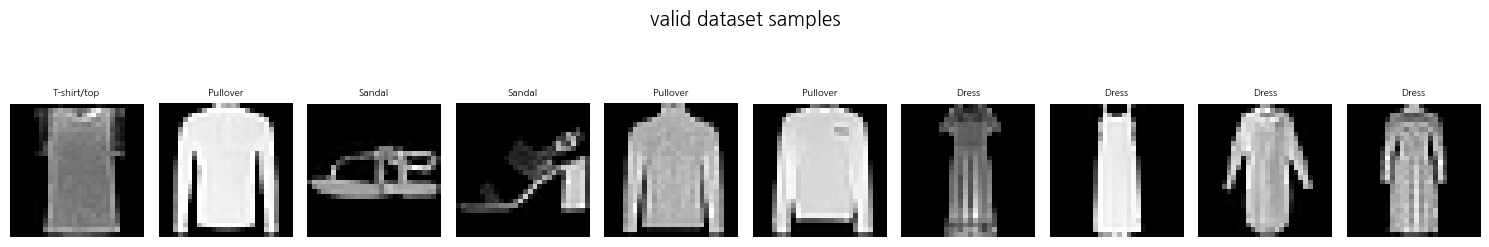

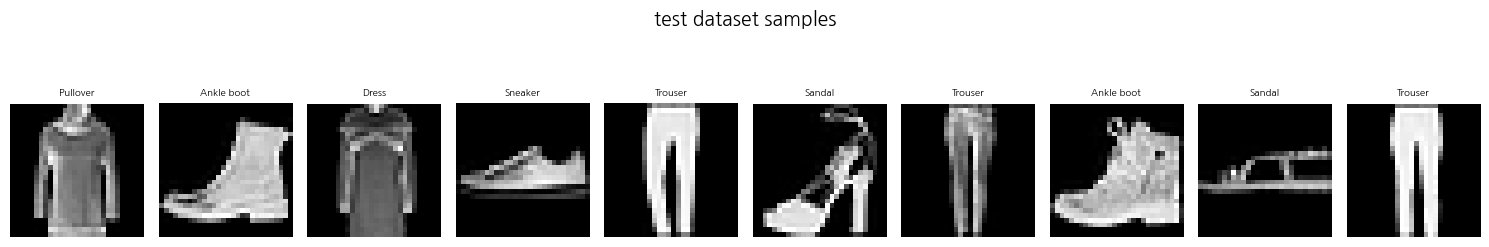

In [ ]:
# 각 데이터셋에서 무작위 샘플 10개 시각화
subsets = {'train': train_subset, 'valid': valid_subset, 'test': test_dataset}

for name, dataset in subsets.items():
    indices = torch.randperm(len(dataset))[:10]
    plt.figure(figsize=(15, 3))
    plt.suptitle(f'{name} dataset samples', fontsize=14)
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        plt.subplot(1, 10, i+1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(classes[label], fontsize=7)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

### DataLoader 생성

DataLoader는 데이터를 **배치(batch) 단위**로 나눠주고, `shuffle=True` 시 매 epoch마다 데이터를 섞어줍니다.
- `batch_size=16` : 한 번에 16개 이미지씩 학습
- `num_workers=2` : 데이터 로딩을 병렬로 처리

In [ ]:
train_loader = DataLoader(train_subset, batch_size=16, shuffle=****,  num_workers=2)
valid_loader = DataLoader(valid_subset, batch_size=16, shuffle=*****, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=*****, num_workers=2)

print('DataLoader 생성 완료!')

DataLoader 생성 완료!


## 3. 학습 헬퍼 함수 정의

반복 사용되는 학습(train), 검증(validate), 체크포인트 저장(save_checkpoint) 함수를 미리 정의합니다.

- **`train()`** : 모델을 훈련 모드로 설정하고, 배치 단위로 순전파 → 손실 계산 → 역전파 → 가중치 업데이트
- **`validate()`** : 모델을 평가 모드로 설정하고 검증 데이터로 손실/정확도 계산 (기울기 계산 없음)
- **`save_checkpoint()`** : 모델 가중치, 학습 기록 등을 `.pth` 파일로 저장

In [ ]:
def train(model, criterion, optimizer, loader):
    """한 epoch 동안 모델을 학습시키고 평균 손실과 정확도를 반환합니다."""
    model.*****()  # 학습 모드 (드롭아웃, 배치정규화 활성화)
    total_loss, total_correct, total_samples = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()           # 이전 기울기 초기화
        outputs = model(images)         # 순전파
        loss = criterion(outputs, labels)  # 손실 계산
        loss.backward()                 # 역전파
        optimizer.step()                # 가중치 업데이트

        total_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples


def *********(model, criterion, loader):
    """검증 데이터로 모델 성능을 평가하고 평균 손실과 정확도를 반환합니다."""
    model.eval()  # 평가 모드 (드롭아웃, 배치정규화 비활성화)
    total_loss, total_correct, total_samples = 0, 0, 0

    with torch.no_grad():  # 기울기 계산 비활성화 (메모리 절약)
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples


def save_checkpoint(epoch, model, save_path, train_losses, val_losses, train_accs, val_accs):
    """모델 가중치와 학습 기록을 파일로 저장합니다."""
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accs,
        'val_accuracies': val_accs,
    }, save_path)
    print(f'  → 체크포인트 저장: {save_path}')

## 4. CNN 모델 정의

### nn.Conv2d 파라미터 설명

```python
nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
```

| 파라미터 | 설명 |
|:---|:---|
| `in_channels` | 입력 이미지의 채널 수 (흑백=1, 컬러=3) |
| `out_channels` | 출력 채널 수 (학습할 필터의 수) |
| `kernel_size` | 필터의 크기 (3이면 3×3) |
| `padding` | 이미지 테두리에 0을 추가해 크기 유지 |

### 모델 구조 요약

```
입력 (1×28×28)
  → Conv1 (32 필터) + ReLU
  → Conv2 (64 필터) + ReLU
  → MaxPool (절반으로 축소: 14×14)
  → Conv3 (128 필터) + ReLU
  → MaxPool (절반으로 축소: 7×7)
  → Flatten (128×7×7 = 6272)
  → FC1 (256) → FC2 (128) → FC3 (10)
출력 (10개 클래스 점수)
```

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # ── 특징 추출부 (Convolutional Layers) ──
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # 1×28×28  → 32×28×28
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32×28×28 → 64×28×28
        self.pool  = nn.MaxPool2d(2, 2)                            # 64×28×28 → 64×14×14
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 64×14×14 → 128×14×14
        self.pool2 = nn.MaxPool2d(2, 2)                            # 128×14×14→ 128×7×7

        # ── 분류부 (Fully Connected Layers) ──
        self.fc1 = nn.Linear(128 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)   # 10개 클래스 출력

    def forward(self, x):
        # 합성곱 → 활성화 함수(ReLU) → 풀링
        x = torch.****(self.conv1(x))
        x = torch.****(self.conv2(x))
        x = self.****(x)                # 28×28 → 14×14
        x = torch.****(self.conv3(x))
        x = self.pool2(x)               # 14×14 → 7×7

        # Flatten: (batch, 128, 7, 7) → (batch, 6272)
        x = x.view(-1, 128 * 7 * 7)

        # 완전연결층
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)                 # 최종 출력 (로짓)
        return x


# 모델 생성 및 GPU로 이동
cnn_model = CNN().to(device)

# 손실함수: 다중 클래스 분류 → CrossEntropyLoss
criterion = nn.CrossEntropyLoss()
# 옵티마이저: Adam (학습률 0.001)
optimizer = optim.****(cnn_model.parameters(), lr=0.001)

print(cnn_model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=6272, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


## 5. 모델 학습

### 조기 종료(Early Stopping)란?

검증 손실이 일정 횟수(`patience`) 이상 개선되지 않으면 학습을 중단합니다.
- 불필요한 학습을 줄여 **과적합(overfitting)을 방지**합니다.
- 가장 좋은 검증 손실일 때의 모델 가중치를 자동 저장합니다.

제 구린 노트북으로도 5분 안에 돌아가요!\
10분이 넘어가면... GPU로 안바꾼 것이니 확인하세요~~!

In [ ]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

num_epochs          = 20
early_stop_patience = 5   # 검증 손실이 5번 연속 개선 없으면 종료
best_val_loss       = float('inf')
early_stop_counter  = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train(cnn_model, criterion, optimizer, train_loader)
    val_loss,   val_acc   = validate(cnn_model, criterion, valid_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f'Epoch {epoch+1:2d}/{num_epochs} | '
          f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}')

    # 검증 손실이 개선될 때 체크포인트 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        save_checkpoint(epoch+1, cnn_model, f'./cnn_best_epoch{epoch+1}.pth',
                        train_losses, val_losses, train_accuracies, val_accuracies)
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print(f'\n조기 종료! (검증 손실 {early_stop_patience}번 연속 미개선)')
            break

print('\n학습 완료!')

Epoch  1/20 | Train Loss: 0.3827, Acc: 0.8609 | Val Loss: 0.2837, Acc: 0.8964
  → 체크포인트 저장: ./cnn_best_epoch1.pth
Epoch  2/20 | Train Loss: 0.2380, Acc: 0.9140 | Val Loss: 0.2671, Acc: 0.9024
  → 체크포인트 저장: ./cnn_best_epoch2.pth
Epoch  3/20 | Train Loss: 0.1852, Acc: 0.9315 | Val Loss: 0.2419, Acc: 0.9131
  → 체크포인트 저장: ./cnn_best_epoch3.pth
Epoch  4/20 | Train Loss: 0.1507, Acc: 0.9438 | Val Loss: 0.2290, Acc: 0.9231
  → 체크포인트 저장: ./cnn_best_epoch4.pth
Epoch  5/20 | Train Loss: 0.1227, Acc: 0.9540 | Val Loss: 0.2410, Acc: 0.9208
Epoch  6/20 | Train Loss: 0.0996, Acc: 0.9632 | Val Loss: 0.2619, Acc: 0.9246
Epoch  7/20 | Train Loss: 0.0817, Acc: 0.9701 | Val Loss: 0.2864, Acc: 0.9246
Epoch  8/20 | Train Loss: 0.0715, Acc: 0.9737 | Val Loss: 0.3222, Acc: 0.9250
Epoch  9/20 | Train Loss: 0.0606, Acc: 0.9780 | Val Loss: 0.3398, Acc: 0.9222

조기 종료! (검증 손실 5번 연속 미개선)

학습 완료!


## 6. 학습 곡선 시각화

**Train Loss < Validation Loss** 이면서 gap이 벌어지면 **과적합(overfitting)** 신호입니다.

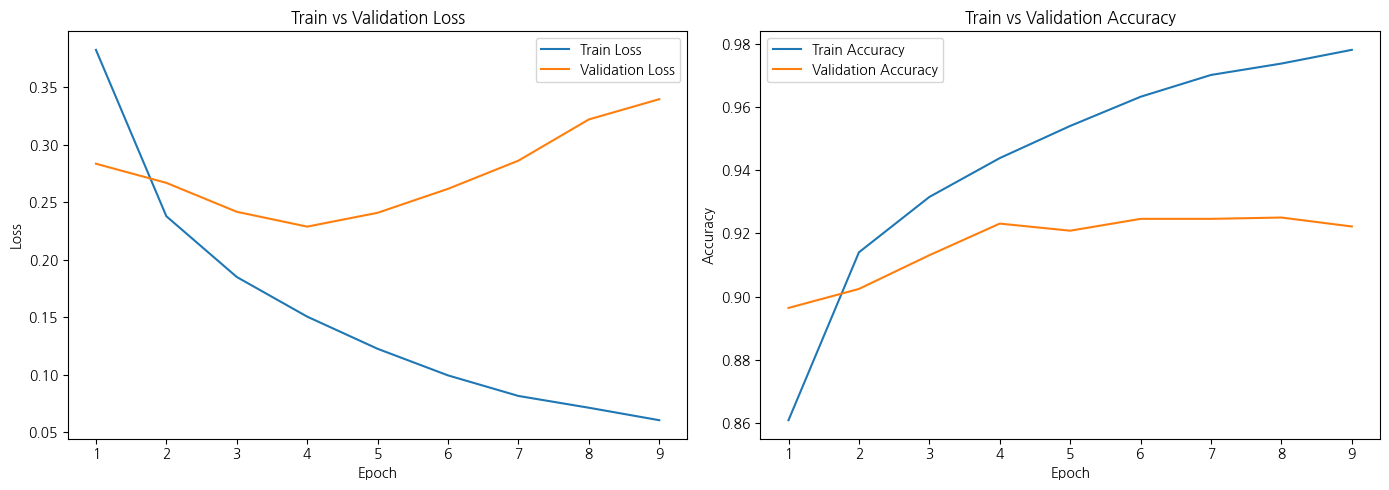

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(train_losses) + 1)

# 손실 그래프
axes[0].plot(epochs_range, train_losses, label='Train Loss')
axes[0].plot(epochs_range, val_losses,   label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Validation Loss')
axes[0].legend()

# 정확도 그래프
axes[1].plot(epochs_range, train_accuracies, label='Train Accuracy')
axes[1].plot(epochs_range, val_accuracies,   label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs Validation Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

시각화로 보니 Epoch8부터 **Train Loss < Validation Loss** 이면서 gap이 확 벌이지는게 보이죠? 바로바로 **과적합(overfitting)** 신호입니다.

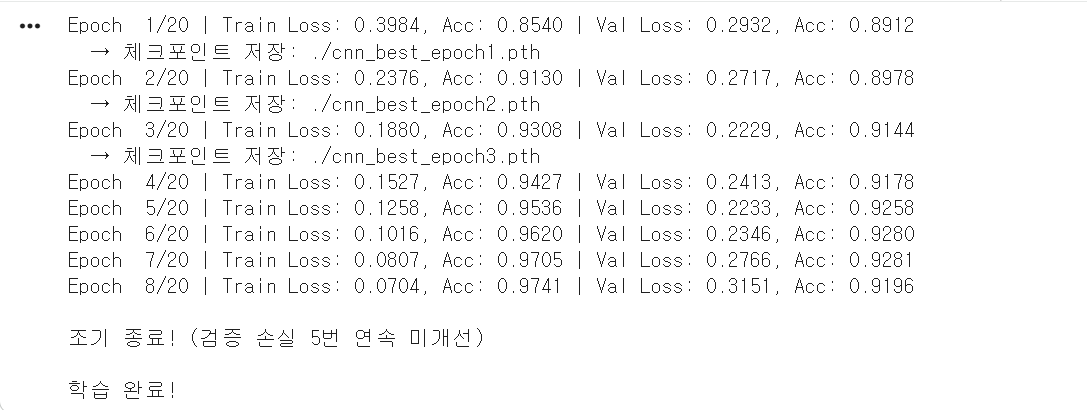

위에서 조기종료된 코드 결과만 봐도, Train Loss는 epoch를 지나가면서 점점 줄어들지만, Validation Loss는 Epoch8부터 다시 증가하는 '과적합'이 일어나는 것을 알 수 있어요!0!

## 7. 테스트 데이터 평가

저장된 체크포인트 중 가장 좋은 모델을 불러와 테스트 데이터로 최종 성능을 측정합니다.

In [ ]:
# ✏️ 가장 좋은 체크포인트 파일 경로를 아래에 입력하세요
# 위에 에포크 돌려본 것과 비교해서 제일 괜찮은 걸로! *에 입력하기!
# (예: './cnn_best_epoch3.pth')

load_path = './cnn_best_epoch*.pth'

checkpoint = torch.load(load_path, map_location=device)
cnn_model.load_state_dict(checkpoint['model_state_dict'])
cnn_model.to(device)

test_loss, test_acc = validate(cnn_model, criterion, test_loader)
print(f'테스트 손실(Loss): {test_loss:.4f}')
print(f'테스트 정확도(Accuracy): {test_acc:.4f}')

## 8. 성능 지표 계산 (Classification Report & Confusion Matrix)

- **Precision (정밀도)** : 예측이 '이 클래스'일 때 실제로 맞은 비율
- **Recall (재현율)** : 실제 '이 클래스'인 것 중 맞게 예측한 비율
- **F1-Score** : Precision과 Recall의 조화 평균
- **Confusion Matrix** : 행=실제 클래스, 열=예측 클래스. 대각선이 클수록 좋은 모델!

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.86      0.86      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.91      0.81      0.86      1000
       Dress       0.91      0.92      0.92      1000
        Coat       0.88      0.83      0.86      1000
      Sandal       0.97      0.99      0.98      1000
       Shirt       0.68      0.81      0.74      1000
     Sneaker       0.96      0.96      0.96      1000
         Bag       1.00      0.95      0.97      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



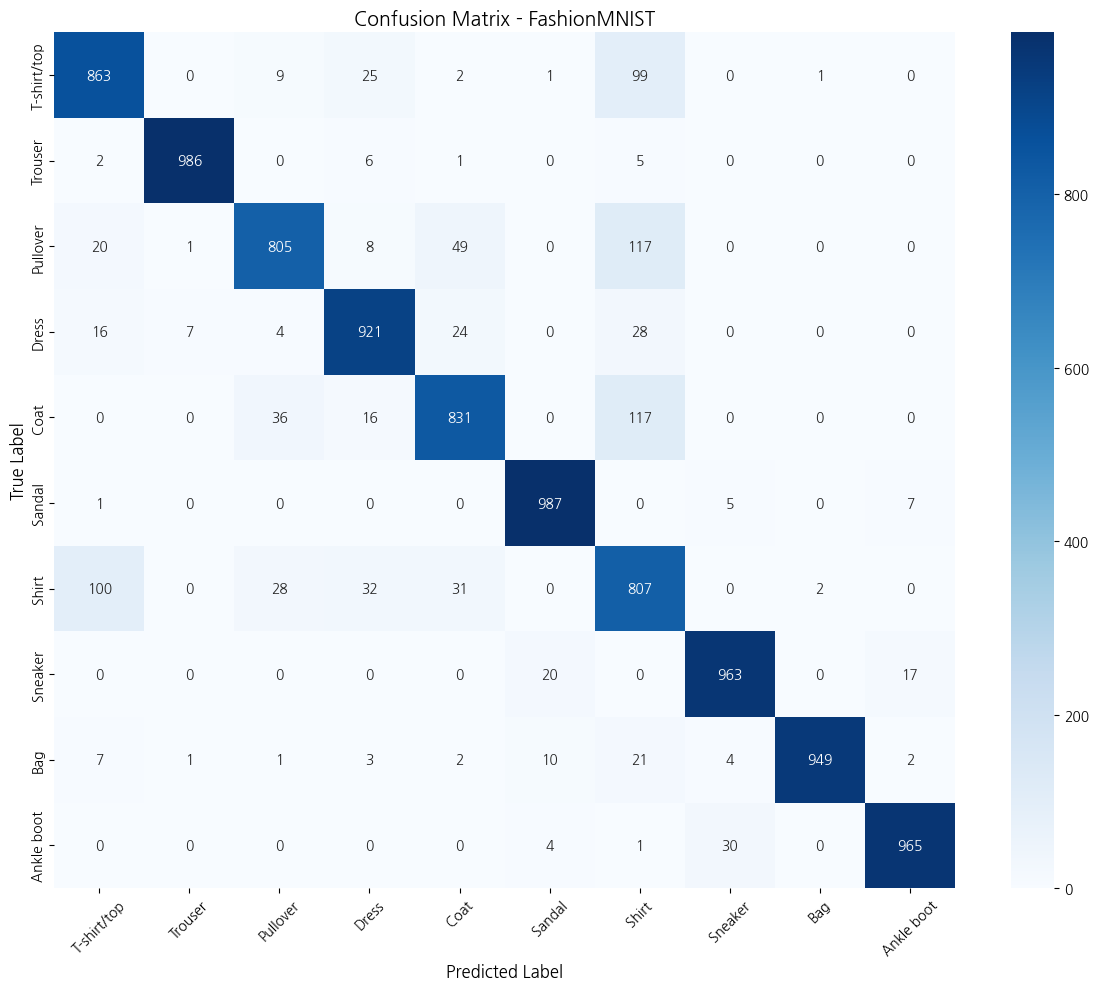

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

cnn_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification Report
print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=classes))

# Confusion Matrix 시각화
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - FashionMNIST', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. 예측 결과 시각화

테스트 이미지 10개를 무작위로 뽑아 예측값과 정답을 비교합니다.
- 🟩 초록 테두리: 예측 성공
- 🟥 빨간 테두리: 예측 실패

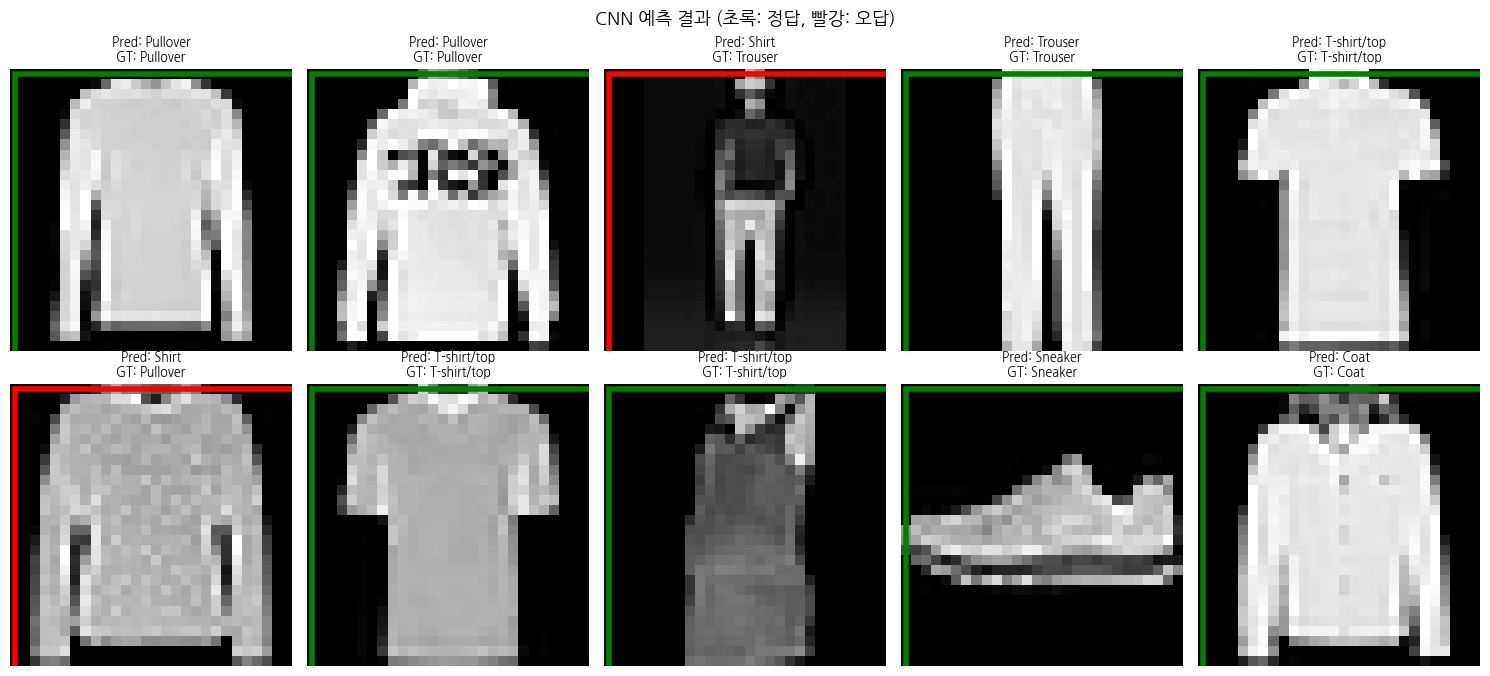

In [ ]:
cnn_model.eval()
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.ravel()

random_indices = random.sample(range(len(test_dataset)), 10)

for i, idx in enumerate(random_indices):
    image, label = test_dataset[idx]
    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = cnn_model(input_tensor)
        pred = torch.argmax(output, dim=1).item()

    image_np = image.squeeze().cpu().numpy()
    axes[i].imshow(image_np, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Pred: {classes[pred]}\nGT: {classes[label]}', fontsize=9)

    color = 'green' if pred == label else 'red'
    h, w = image_np.shape
    rect = patches.Rectangle((0, 0), w, h, linewidth=4,
                               edgecolor=color, facecolor='none')
    axes[i].add_patch(rect)

plt.suptitle('CNN 예측 결과 (초록: 정답, 빨강: 오답)', fontsize=13)
plt.tight_layout()
plt.show()

---

# 🔄 PART 2. RNN을 활용한 시계열 예측 (사인 함수)

## RNN이란?

**RNN(Recurrent Neural Network, 순환 신경망)** 은 시퀀스(순서가 있는) 데이터를 처리하기 위한 신경망입니다.

일반 신경망(MLP)과의 가장 큰 차이점은 바로 **'기억'** 입니다:
- MLP는 각 입력을 독립적으로 처리합니다 → 이전 데이터를 기억하지 못함
- RNN은 이전 시점의 출력(은닉 상태, $h_{t-1}$)을 현재 시점의 입력과 함께 사용합니다 → **이전 정보를 기억!**

## RNN 계산식

$$h_t = \tanh(W_x \cdot x_t + W_h \cdot h_{t-1} + b)$$
$$y_t = W_y \cdot h_t + b_y$$

| 기호 | 의미 |
|:---|:---|
| $x_t$ | 현재 시점(t)의 입력 |
| $h_{t-1}$ | 이전 시점(t-1)의 은닉 상태 ("기억") |
| $h_t$ | 현재 시점(t)의 새로운 은닉 상태 |
| $W_x, W_h$ | 학습되는 가중치 행렬 |
| $\tanh$ | 활성화 함수 (출력 범위: -1 ~ 1) |

이 구조 덕분에 RNN은 시간 순서대로 정보를 누적하며 처리할 수 있습니다!

## 0. 라이브러리 불러오기

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(333)

## 1. 데이터 준비: 사인(sin)함수 생성
RNN 학습에 사용할 데이터로 **사인 함수**를 사용합니다.\
사인 함수는 완벽한 주기를 가진 데이터로, RNN이 **'이전 패턴을 기억해서 다음 값을 예측'** 하는 것을 확인하기에 딱 좋습니다!

In [ ]:
# 시각화 전 한글폰트 안 깨지도록
!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 경로 직접 추가 (🔥 이게 핵심)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

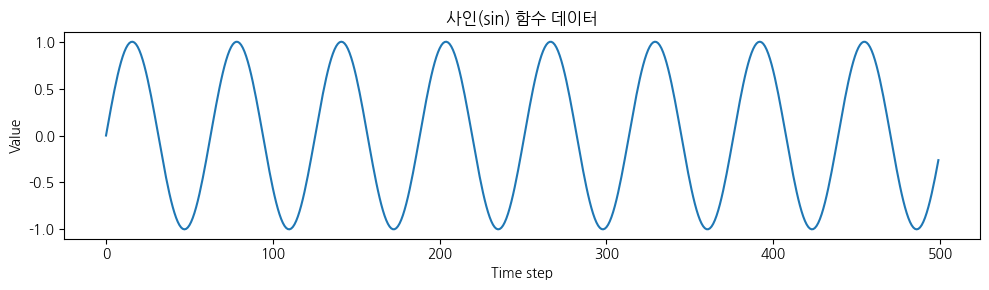

In [ ]:
def generate_sine_wave(num_samples=500):
    """sin 함수 데이터를 생성합니다."""
    x = np.linspace(0, 50, num_samples)
    y = np.sin(x)
    return y

data = generate_sine_wave()

plt.figure(figsize=(10, 3))
plt.plot(data)
plt.title('사인(sin) 함수 데이터')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

## 2. 시퀀스 데이터 생성

RNN에 입력할 형태로 데이터를 변환합니다.

예시 (seq_length=3):
입력(X): [sin(0), sin(1), sin(2)] → 정답(y): sin(3)
입력(X): [sin(1), sin(2), sin(3)] → 정답(y): sin(4)
...

즉, **과거 seq_length개**의 데이터를 보고 **다음 1개 값**을 예측하는 구조입니다.

In [ ]:
def create_sequences_rnn(data, seq_length):
    """
    연속된 seq_length개 데이터를 입력으로,
    그 다음 값을 정답으로 만드는 함수입니다.
    """
    sequences, labels = [], []
    for i in range(len(data) - seq_length):
        sequences.append(data[i : i + seq_length]) # 입력: seq_length개 연속 데이터
        labels.append(data[i + seq_length]) # 정답: 바로 다음 값

    # unsqueeze(-1): (샘플 수, seq_length) → (샘플 수, seq_length, 1)
    # RNN 입력 형태: (batch_size, seq_length, input_size)
    sequences = torch.******(np.array(sequences), dtype=torch.float32).unsqueeze(-1)
    labels = torch.******(np.array(labels), dtype=torch.float32)
    return sequences, labels


seq_length = 50
X, y = create_sequences_rnn(data, seq_length)

print(f'X shape: {X.shape} ← (샘플 수, 시퀀스 길이, 입력 크기)')
print(f'y shape: {y.shape} ← (샘플 수,)')

X shape: torch.Size([450, 50, 1]) ← (샘플 수, 시퀀스 길이, 입력 크기)
y shape: torch.Size([450]) ← (샘플 수,)


## 3. RNN 모델 정의

RNN 모델은 크게 두 부분으로 구성됩니다:

### 1. init (초기화)
* 각 레이어에서 사용할 가중치 행렬(nn.Linear)을 미리 정의합니다.
* i2h: Input → Hidden
* h2h: Hidden → Hidden
* fc: Hidden → Output
### 2. forward (순전파)
* 데이터가 실제로 모델을 통과하는 과정
* for t in range(seq_len)로 시점별 처리
* 핵심: 현재 입력($x_t$) + 이전 상태($h_{t-1}$)

In [ ]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        """
        input_size : 입력 데이터의 크기 (사인 함수의 경우 1)
        hidden_size : 은닉 상태의 차원 (기억 용량)
        num_layers : RNN을 몇 층 쌓을지
        """
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.layers = nn.ModuleList()
        for i in range(num_layers):
            layer_input_size = input_size if i == 0 else hidden_size
            i2h = nn.Linear(layer_*****_size, ******_size)
            h2h = nn.Linear(******_size, ******_size)
            self.layers.append(nn.ModuleDict({'i2h': i2h, 'h2h': h2h}))

        self.tanh = nn.Tanh()
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        device = x.device
        batch_size = x.shape[0]
        seq_len = x.shape[1]

        h_prev_layers = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)

        final_outputs = []

        for t in range(seq_len):
            x_t = x[:, t, :]
            current_input = x_t
            h_current_layers = []

            for l in range(self.num_layers):
                h_prev = h_prev_layers[l]
                i2h = self.layers[l]['i2h']
                h2h = self.layers[l]['h2h']

                h_next = self.tanh(i2h(current_input) + h2h(h_prev))

                h_current_layers.append(h_next)
                current_input = h_next

            h_prev_layers = torch.stack(h_current_layers)
            final_outputs.append(h_next)

        out = torch.stack(final_outputs).transpose(0, 1)
        h_T = out[:, -1, :]
        return self.fc(h_T)

## 4. 모델 학습

학습에서 꼭 알아야하는 코드들 !!
* optimizer.zero_grad()   # 1. 기울기 초기화
* outputs = model(X)      # 2. 순전파
* loss = loss_fn(outputs, y)  # 3. 손실 계산
* loss.backward()         # 4. 역전파 (기울기 계산)
* optimizer.step()        # 5. 가중치 업데이트

In [ ]:
input_size = 1
hidden_size = 20
num_layers = 2

rnn_model = SimpleRNN(input_size, hidden_size, num_layers)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(rnn_model.parameters(), lr=0.001)

epochs = 100
for epoch in range(epochs):
  #모델 학습은 어떻게 시켰죠? 아래 빈칸에 넣으면 됩니다!
    rnn_model.*****()
    # 이전 배치에서 계산된 기울기(gradient)를 초기화하려면?
    optimizer.****_****()
    outputs = rnn_model(X)
    loss = loss_fn(outputs.squeeze(), y)
    loss.********() # 역전파
    optimizer.****() # 가중치 업데이트

    if epoch % 10 == 0:
        print(f'Epoch [{epoch:3d}/{epochs}], Loss: {loss.item():.6f}')

print('\nRNN 학습 완료!')

Epoch [  0/100], Loss: 0.510524
Epoch [ 10/100], Loss: 0.127642
Epoch [ 20/100], Loss: 0.038059
Epoch [ 30/100], Loss: 0.033306
Epoch [ 40/100], Loss: 0.023545
Epoch [ 50/100], Loss: 0.020007
Epoch [ 60/100], Loss: 0.016758
Epoch [ 70/100], Loss: 0.014309
Epoch [ 80/100], Loss: 0.012384
Epoch [ 90/100], Loss: 0.010588

RNN 학습 완료!


## 5. 예측 결과 시각화

RNN이 사인 함수의 패턴을 얼마나 잘 학습했는지 확인합니다.

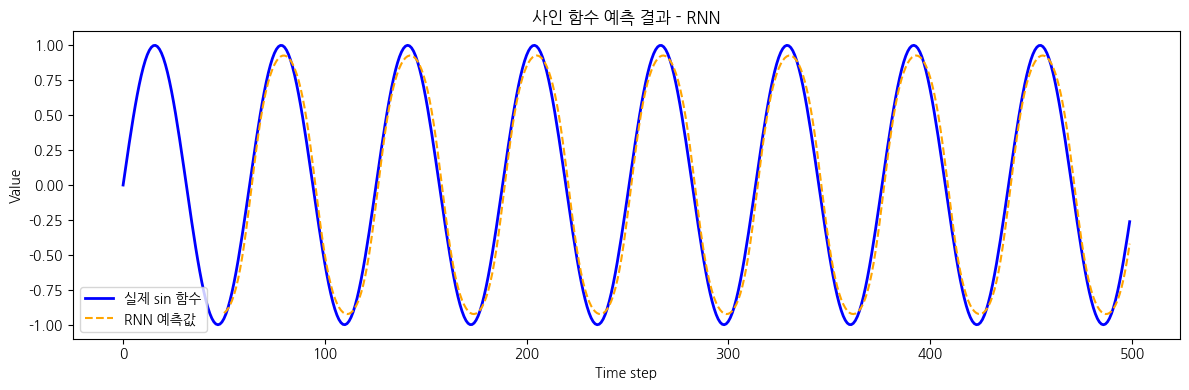

In [ ]:
rnn_model.eval()
with torch.no_grad():
    predictions = rnn_model(X).numpy()

plt.figure(figsize=(12, 4))
plt.plot(data, label='실제 sin 함수', color='blue', linewidth=2)
plt.plot(
    range(seq_length, seq_length + len(predictions)),
    predictions,
    label='RNN 예측값',
    linestyle='dashed',
    color='orange'
)
plt.legend()
plt.title('사인 함수 예측 결과 - RNN')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

## 6. RNN의 한계: 장기 의존성 문제

사인 함수처럼 **단순하고 짧은 패턴**에서는 RNN이 잘 동작합니다.  
하지만 시퀀스가 길어지거나 데이터가 복잡해지면 **문제가 발생합니다.**

### 왜 문제가 생길까요?

역전파 과정에서 기울기(gradient)가 시간을 거슬러 전파될 때,  
기울기가 **소실(vanishing)** 되거나 **폭발(exploding)** 합니다.\
현재 ←──── 어제 ←──── 1주일 전 ←──── 1달 전 ...
(점점 약해짐)\

→ 오래된 정보가 반영되지 않음  
→ 이것이 **장기 의존성 문제 (Long-Term Dependency Problem)**

---

### 해결책: LSTM과 GRU

다음 PART에서 배울 **LSTM / GRU**는  
**게이트(Gate) 메커니즘**을 사용해  
기억을 **선택적으로 유지/삭제**합니다.

---

# 📈 PART 3. LSTM / GRU를 활용한 시계열 예측 (삼성전자 주가)

이제 RNN의 한계를 극복한 **LSTM**과 **GRU**를 사용합니다!

## LSTM vs GRU 핵심 비교

| 항목 | RNN | LSTM | GRU |
|:---|:---|:---|:---|
| 상태 | 은닉 상태(h)만 | 은닉 상태(h) + **셀 상태(c)** | 은닉 상태(h)만 |
| 게이트 수 | 없음 | **3개** (Forget, Input, Output) | **2개** (Reset, Update) |
| 장기 기억 | ❌ 어려움 | ✅ 가능 | ✅ 가능 |
| 속도/파라미터 | 빠름 / 적음 | 느림 / 많음 | 중간 |

## 0. 라이브러리 불러오기 & 시드 고정

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, MinMaxScaler

torch.manual_seed(125)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('사용 장치:', device)

사용 장치: cuda:0


## 1. 삼성전자 주가 데이터 가져오기

`yfinance` 라이브러리로 삼성전자(종목코드: 005930.KS)의 주가를 불러옵니다.

- **종가(Close)** 를 예측 대상(y)으로 사용
- **시가(Open), 고가(High), 저가(Low), 거래량(Volume)** 을 입력 피처(X)로 사용

In [ ]:
import yfinance as yf

df = yf.download('005930.KS',
                 start='2025-01-01',
                 end='2025-05-31')
print(df.shape)
df.head()

/tmp/ipykernel_893/3334461155.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('005930.KS',
[*********************100%***********************]  1 of 1 completed

(99, 5)


Price,Close,High,Low,Open,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2025-01-02,52164.558594,52359.931472,51090.007761,51480.753519,16630538
2025-01-03,53141.421875,53825.226936,51578.438879,51578.438879,19318046
2025-01-06,54606.718750,54899.778064,53043.735745,53141.422182,19034284
2025-01-07,54118.289062,55974.331467,54118.289062,55485.899255,17030235
2025-01-08,55974.328125,56169.700998,53434.480776,53532.167212,26593553


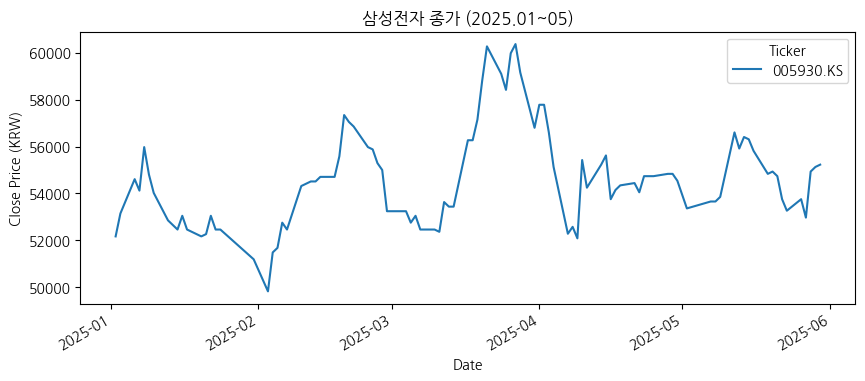

In [ ]:
# 종가 추이 시각화
df['Close'].plot(figsize=(10, 4), title='삼성전자 종가 (2025.01~05)')
plt.ylabel('Close Price (KRW)')
plt.show()

## 2. 데이터 전처리

### 스케일링이 필요한 이유
주가, 거래량 등 피처 간 크기(단위) 차이가 매우 크면 학습이 불안정해집니다.
- **X (입력 피처)** → `StandardScaler` : 평균 0, 표준편차 1로 정규화
- **y (종가)** → `MinMaxScaler` : 0~1 범위로 정규화 (나중에 원래 단위로 역변환 가능)

### 시퀀스 데이터 생성
시계열 예측에서는 **'과거 N일'의 데이터를 입력으로 받아 '다음 날'을 예측**합니다.  
이 N을 `seq_length`(시퀀스 길이)라고 합니다.

In [ ]:
# X, y 분리
X = df.drop('Close', axis=1)
y = df[['Close']]

# 스케일링
ss = **************()
ms = ************()
X_ss = ss.fit_transform(X)
y_ms = ms.fit_transform(y)

def create_sequences(data_x, data_y, seq_length):
    """과거 seq_length일치 데이터(X)와 다음 날 종가(y)로 시퀀스를 생성합니다."""
    sequences, labels = [], []
    for i in range(len(data_x) - seq_length):
        sequences.append(data_x[i : i + seq_length])   # 입력: i ~ i+seq_length-1 일
        labels.append(data_y[i + seq_length])           # 정답: i+seq_length 일의 종가
    sequences = torch.******(np.array(sequences), dtype=torch.float32)
    labels    = torch.******(np.array(labels),    dtype=torch.float32)
    return sequences, labels

seq_length = 10  # 10일치 데이터를 보고 다음 날 예측
X_t, y_t = create_sequences(X_ss, y_ms, seq_length)

print(f'입력(X) shape: {X_t.shape}  ← (샘플 수, 시퀀스 길이, 피처 수)')
print(f'정답(y) shape: {y_t.shape}  ← (샘플 수, 1)')

입력(X) shape: torch.Size([89, 10, 4])  ← (샘플 수, 시퀀스 길이, 피처 수)
정답(y) shape: torch.Size([89, 1])  ← (샘플 수, 1)


In [ ]:
# 훈련/테스트 분리
train_size = 79 - seq_length  # 약 70일치 훈련

X_train = X_t[:train_size].to(device)
X_test  = X_t[train_size:].to(device)
y_train = y_t[:train_size].to(device)
y_test  = y_t[train_size:].to(device)

print(f'훈련 데이터: X={X_train.shape}, y={y_train.shape}')
print(f'테스트 데이터: X={X_test.shape},  y={y_test.shape}')

훈련 데이터: X=torch.Size([69, 10, 4]), y=torch.Size([69, 1])
테스트 데이터: X=torch.Size([20, 10, 4]),  y=torch.Size([20, 1])


## 3. LSTM 모델

### LSTM의 핵심 아이디어

LSTM은 **게이트(Gate)** 메커니즘으로 정보를 선별적으로 기억/망각합니다.

| 게이트 | 역할 |
|:---|:---|
| **Forget Gate (f)** | 이전 기억(c_{t-1})에서 얼마나 잊을지 결정 |
| **Input Gate (i)** | 새로운 정보를 얼마나 기억할지 결정 |
| **Output Gate (o)** | 현재 기억을 얼마나 출력할지 결정 |

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$h_t = o_t \odot \tanh(c_t)$$

여기서는 복잡한 직접 구현 대신, PyTorch의 **`nn.LSTM`** 을 사용해 간결하게 구현합니다.

In [ ]:
class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        """
        input_size  : 입력 피처 수 (Open, High, Low, Volume = 4)
        hidden_size : LSTM 은닉 상태 차원
        num_layers  : 쌓을 LSTM 레이어 수
        num_classes : 출력 수 (종가 1개 예측 → 1)
        """
        super(SimpleLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # nn.LSTM: PyTorch 내장 LSTM 레이어
        # batch_first=True → 입력 shape: (batch, seq, feature)
        self.lstm = **.****(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True)

        # 출력층: hidden_size → 128 → 1
        self.fc1  = nn.Linear(hidden_size, 128)
        self.fc2  = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        # 초기 은닉/셀 상태를 0으로 초기화
        h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # LSTM 통과
        # output: (batch, seq, hidden) - 모든 시점의 은닉 상태
        # hn:     (num_layers, batch, hidden) - 마지막 시점 은닉 상태
        output, (hn, cn) = self.lstm(x, (h_0, c_0))

        # 마지막 레이어의 마지막 시점 은닉 상태 사용
        out = hn[-1]           # (batch, hidden)
        out = self.relu(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)    # (batch, 1)
        return out

In [ ]:
# LSTM 모델 학습
# 빈칸을 모르겠다면 RNN 학습 부분으로 다!시! 가시면 됩니다!!
lstm_model = SimpleLSTM(input_size=4, hidden_size=64,
                         num_layers=1, num_classes=1).to(device)

criterion  = nn.MSELoss()
optimizer  = optim.Adam(lstm_model.parameters(), lr=0.0001)
num_epochs = 500

lstm_model.train()
for epoch in range(num_epochs):
    outputs = lstm_*****(X_train)
    optimizer.****_****() # 기울기 초기화
    loss = criterion(outputs, y_train)
    loss.********() # 역전파
    optimizer.****() # 가중치 업데이트
    if epoch % 100 == 0:
        print(f'[LSTM] Epoch {epoch:4d}/{num_epochs} | Loss: {loss.item():.6f}')

print('\nLSTM 학습 완료!')

[LSTM] Epoch    0/500 | Loss: 0.272724
[LSTM] Epoch  100/500 | Loss: 0.106421
[LSTM] Epoch  200/500 | Loss: 0.018037
[LSTM] Epoch  300/500 | Loss: 0.010804
[LSTM] Epoch  400/500 | Loss: 0.008781

LSTM 학습 완료!


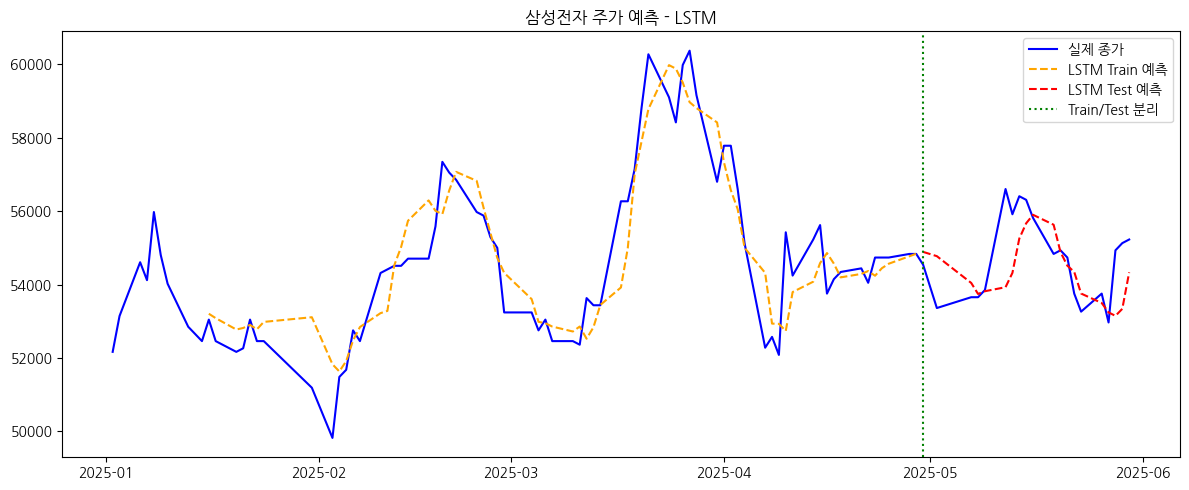

In [ ]:
# LSTM 예측 & 시각화
lstm_model.eval()
with torch.no_grad():
    train_pred_lstm = ms.inverse_*********(lstm_model(X_train).cpu().numpy())
    test_pred_lstm  = ms.inverse_*********(lstm_model(X_test).cpu().numpy())

actual_close = df['Close'].values

train_plot = np.full_like(actual_close, np.nan, dtype=float)
train_plot[seq_length : train_size + seq_length] = train_pred_lstm

test_plot = np.full_like(actual_close, np.nan, dtype=float)
test_plot[train_size + seq_length :] = test_pred_lstm

plt.figure(figsize=(12, 5))
plt.plot(df.index, actual_close,    label='실제 종가',          color='blue')
plt.plot(df.index, train_plot,       label='LSTM Train 예측',   color='orange', linestyle='--')
plt.plot(df.index, test_plot,        label='LSTM Test 예측',    color='red',    linestyle='--')
plt.axvline(x=df.index[train_size + seq_length], color='green', linestyle=':', label='Train/Test 분리')
plt.title('삼성전자 주가 예측 - LSTM')
plt.legend()
plt.tight_layout()
plt.show()

## 4. GRU 모델

### GRU의 핵심 아이디어

GRU는 LSTM보다 **구조가 단순**합니다. 셀 상태(c_t)가 없고 게이트도 2개뿐입니다.

| 게이트 | 역할 |
|:---|:---|
| **Reset Gate (r)** | 과거 정보(h_{t-1})를 얼마나 무시할지 결정 |
| **Update Gate (z)** | 과거와 새 정보의 비중을 결정 (LSTM의 Forget+Input 역할) |

$$h_t = (1-z_t) \odot \tilde{h}_t + z_t \odot h_{t-1}$$

여기서도 **`nn.GRU`** 를 사용해 간결하게 구현합니다.

In [ ]:
class SimpleGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        """
        input_size  : 입력 피처 수 (4)
        hidden_size : GRU 은닉 상태 차원
        num_layers  : 쌓을 GRU 레이어 수
        num_classes : 출력 수 (1)
        """
        super(SimpleGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # nn.GRU: PyTorch 내장 GRU 레이어
        # LSTM과 달리 셀 상태(c)가 없으므로 반환값이 (output, hn)뿐
        self.gru = **.***(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          batch_first=True)

        # 출력층: hidden_size → 128 → 1
        self.fc1  = nn.Linear(hidden_size, 128)
        self.fc2  = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        # GRU는 셀 상태(c_0)가 필요 없음
        h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # output: (batch, seq, hidden)
        # hn:     (num_layers, batch, hidden)
        output, hn = self.gru(x, h_0)

        # 마지막 시점의 출력 사용 (LSTM과 동일)
        out = output[:, -1, :]  # (batch, hidden)
        out = self.relu(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)     # (batch, 1)
        return out

In [ ]:
# GRU 모델 학습
gru_model = SimpleGRU(input_size=4, hidden_size=64,
                       num_layers=1, num_classes=1).to(device)

criterion_gru = nn.MSELoss()
optimizer_gru = optim.Adam(gru_model.parameters(), lr=0.0001)

gru_model.train()
for epoch in range(num_epochs):
    outputs = gru_*****(X_train)
    optimizer_gru.****_****() # 기울기 초기화
    loss = criterion_gru(outputs, y_train)
    loss.backward()
    optimizer_gru.****() # 가중치 업데이트
    if epoch % 100 == 0:
        print(f'[GRU] Epoch {epoch:4d}/{num_epochs} | Loss: {loss.item():.6f}')

print('\nGRU 학습 완료!')

[GRU] Epoch    0/500 | Loss: 0.220831
[GRU] Epoch  100/500 | Loss: 0.046238
[GRU] Epoch  200/500 | Loss: 0.015334
[GRU] Epoch  300/500 | Loss: 0.009247
[GRU] Epoch  400/500 | Loss: 0.007611

GRU 학습 완료!


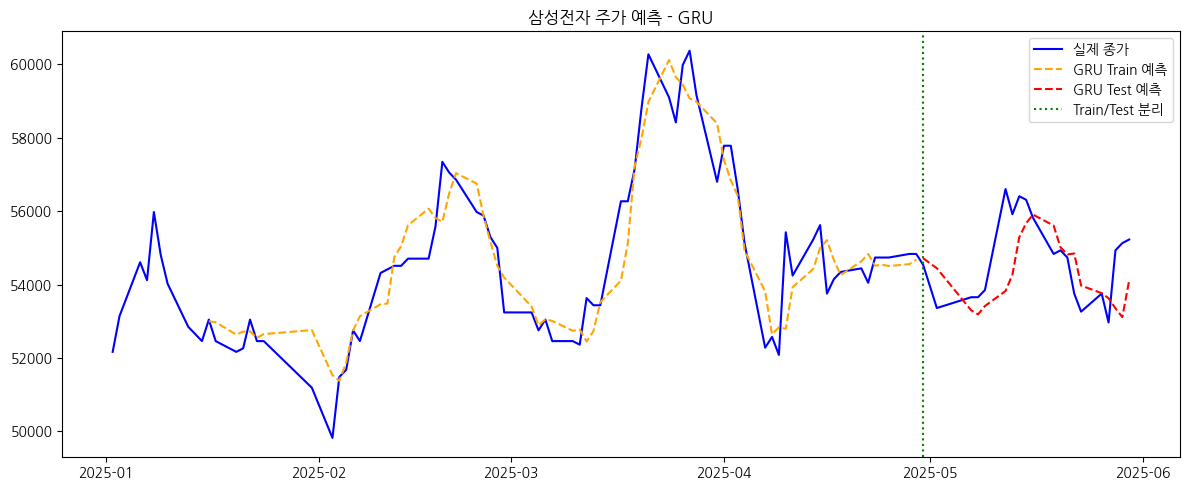

In [ ]:
# GRU 예측 & 시각화
gru_model.eval()
with torch.no_grad():
    train_pred_gru = ms.inverse_*********(gru_model(X_train).cpu().numpy())
    test_pred_gru  = ms.inverse_*********(gru_model(X_test).cpu().numpy())

train_plot_gru = np.full_like(actual_close, np.nan, dtype=float)
train_plot_gru[seq_length : train_size + seq_length] = train_pred_gru

test_plot_gru = np.full_like(actual_close, np.nan, dtype=float)
test_plot_gru[train_size + seq_length :] = test_pred_gru

plt.figure(figsize=(12, 5))
plt.plot(df.index, actual_close,      label='실제 종가',        color='blue')
plt.plot(df.index, train_plot_gru,     label='GRU Train 예측', color='orange', linestyle='--')
plt.plot(df.index, test_plot_gru,      label='GRU Test 예측',  color='red',    linestyle='--')
plt.axvline(x=df.index[train_size + seq_length], color='green', linestyle=':', label='Train/Test 분리')
plt.title('삼성전자 주가 예측 - GRU')
plt.legend()
plt.tight_layout()
plt.show()

## 5. LSTM vs GRU 성능 비교

두 모델의 테스트 예측값을 한 그래프에서 비교합니다.

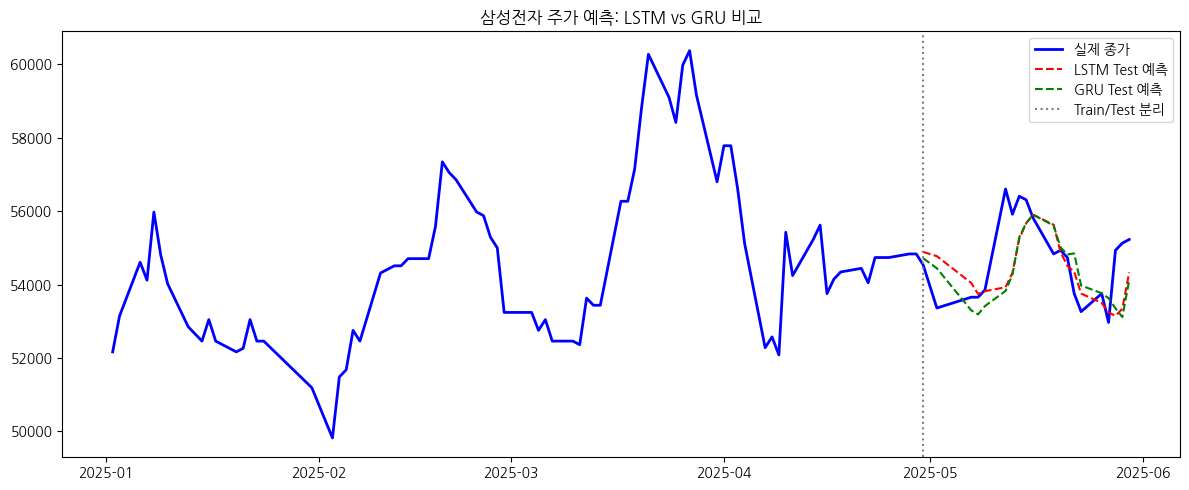

LSTM Test MSE: 1,117,770.75
GRU  Test MSE: 1,219,046.62

→ MSE가 낮을수록 예측이 실제값에 가깝습니다.


In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, actual_close,    label='실제 종가',         color='blue',   linewidth=2)
plt.plot(df.index, test_plot,        label='LSTM Test 예측',  color='red',    linestyle='--')
plt.plot(df.index, test_plot_gru,    label='GRU Test 예측',   color='green',  linestyle='--')
plt.axvline(x=df.index[train_size + seq_length], color='gray', linestyle=':', label='Train/Test 분리')
plt.title('삼성전자 주가 예측: LSTM vs GRU 비교')
plt.legend()
plt.tight_layout()
plt.show()

# MSE 수치 비교
from sklearn.metrics import mean_squared_error

y_test_actual = ms.inverse_transform(y_test.cpu().numpy())

mse_lstm = mean_squared_error(y_test_actual, test_pred_lstm)
mse_gru  = mean_squared_error(y_test_actual, test_pred_gru)

print(f'LSTM Test MSE: {mse_lstm:,.2f}')
print(f'GRU  Test MSE: {mse_gru:,.2f}')
print(f'\n→ MSE가 낮을수록 예측이 실제값에 가깝습니다.')

---

## 🎓 전체 정리

### PART 1 (CNN 이미지 분류)
- Conv2d + MaxPool2d로 이미지의 **공간 특징**을 추출합니다.  
- **Early Stopping**으로 과적합을 방지하고, 최적 가중치를 저장합니다.

---

### PART 2 (RNN - 사인 함수 예측) ⭐
- RNN은 **은닉 상태($h_t$)** 를 통해 이전 정보를 다음 시점으로 전달합니다.  
- **핵심 계산식**: $h_t = \tanh(W_x x_t + W_h h_{t-1})$  
- 단순한 패턴에는 효과적이지만, 긴 시퀀스에서는 **장기 의존성 문제**가 발생합니다.

---

### PART 3 (LSTM / GRU - 주가 예측)
- **LSTM**: 3개 게이트 + 셀 상태($c_t$)로 장기 의존성 문제를 해결합니다.  
- **GRU**: 2개 게이트만으로 LSTM을 단순화했습니다. 더 빠르고 파라미터가 적습니다.  
- `nn.LSTM` / `nn.GRU` 내장 함수로 간결하게 구현했습니다.

---

## 🎉 수고하셨습니다!